# PyMC-10 : Sélection de Modèles et Comparaison Bayesienne

**Navigation** : [Index](../README.md) | [<< PyMC-9](PyMC-9-Classification.ipynb) | [PyMC-11 >>](PyMC-11-Topic-Models.ipynb)

**Equivalent Infer.NET** : [Infer-10-Model-Sélection](../Infer/Infer-10-Model-Selection.ipynb)


**Duree estimee** : 60 minutes
**Objectifs** :
- Comprendre le problème du surapprentissage (overfitting)
- Comparer des modèles via le critere WAIC et la validation croisee LOO
- Implementer l'ARD (Automatic Relevance Determination) pour la sélection de variables
- Utiliser les Bayes Factors pour la sélection de composantes dans les melanges
- Comparer Infer.NET (calcul exact de l'evidence) vs PyMC/ArviZ (WAIC/LOO)

**Prerequis** : PyMC-1 a PyMC-9, comparaison de modèles (WAIC/LOO)

## Contexte et motivation

La sélection de modèles est l'un des problèmes centraux de l'inférence bayésienne : étant
donné un jeu de données et plusieurs hypothèses (modèles) candidates, comment choisir celle
qui généralisera le mieux ? Les fréquentistes répondent par la validation croisée ou des
critères type AIC/BIC ; les bayésiens disposent d'un levier théorique direct — **l'evidence**
(marginal likelihood) — qui pondère naturellement la complexité par l'ajustement aux données.

**Trois echelles de complexité** sont abordées dans ce notebook :
1. **Sélection de composantes** (1 vs 2 gaussiennes) : une seule variable latente catégorielle,
   l'evidence tranche de manière décisive grâce à la pénalisation automatique d'OCcam.
2. **Sélection de variables** (ARD) : un prior hiérarchique Gamma sur la précision de chaque
   poids ; les variables non pertinentes voient leur poids posteriors concentrés vers 0.
3. **Sélection de complexité** (polynômes degré 1/2/3) : WAIC et LOO pinalisent les modèles
   sur-paramétrés sans avoir à cross-valuer explicitement.

**Pourquoi WAIC/LOO et pas l'evidence directement ?** Parce que l'evidence nécessite d'intégrer
sur l'espace des paramètres — c'est exactement ce que NUTS fait mal (les divergences apparaissent
dans les régions de faible posterior). ArviZ contourne le problème en approximant l'evidence
hors-échantillon via le **Pareto Smoothed Importance Sampling (PSIS)** de Vehtari et al. (2017),
qui produit une estimation stable du leave-one-out predictive accuracy.

**Reference** : Vehtari, Gelman, Gabry (2017), *Pareto Smoothed Importance Sampling Pointwise
Predictive Model Selection*, Statistics and Computing 27(5). DOI : 10.1007/s11222-016-9696-4.


In [1]:
import warnings

# Trois familles d'avertissements Python apparaissent dans ce notebook :
#  1. arviz FutureWarning (refactor advisory) et pytensor "could not link BLAS" (advisory de perf,
#     pas de correctness) : bruit sans valeur pedagogique -> on les filtre.
#  2. Les diagnostics de convergence (WAIC, R-hat, ESS) sont AU CONTRAIRE des alertes utiles
#     (le notebook porte precisement sur la selection de modele) -> on les GARDE visibles,
#     mais on retire le prefixe de chemin absolu (qui fuiterais le chemin local site-packages).
warnings.filterwarnings("ignore", category=FutureWarning, module="arviz")
warnings.filterwarnings("ignore", message=".*could not link.*", category=UserWarning)


def _warn_no_path(message, category, filename, lineno, file=None, line=None):
    """Affiche le warning SANS le chemin absolu du fichier source (anti path-leak #3436)."""
    return f"{category.__name__}: {message}\n"


warnings.formatwarning = _warn_no_path

try:
    import numpy as np
    NUMPY_AVAILABLE = True
except ImportError:
    NUMPY_AVAILABLE = False

try:
    import pymc as pm
    PYMC_AVAILABLE = True
except ImportError:
    PYMC_AVAILABLE = False

try:
    import pytensor.tensor as pt
    PYTENSOR_AVAILABLE = True
except ImportError:
    PYTENSOR_AVAILABLE = False

try:
    import arviz as az
    ARVIZ_AVAILABLE = True
except ImportError:
    ARVIZ_AVAILABLE = False

try:
    import matplotlib.pyplot as plt
    MATPLOTLIB_AVAILABLE = True
except ImportError:
    MATPLOTLIB_AVAILABLE = False

try:
    from scipy import stats
    SCIPY_AVAILABLE = True
except ImportError:
    SCIPY_AVAILABLE = False

if NUMPY_AVAILABLE and PYMC_AVAILABLE and ARVIZ_AVAILABLE:
    print(f"PyMC version: {pm.__version__}")
    print(f"ArviZ version: {az.__version__}")
    az.style.use("arviz-darkgrid")
else:
    print("PyMC ou ArviZ n'est pas installe. Executez: pip install pymc arviz matplotlib numpy scipy")

PyMC version: 5.28.5
ArviZ version: 0.23.4


## 1. Le Problème du Surapprentissage

Un modèle trop complexe peut memoriser le bruit dans les données au lieu d'apprendre le signal.
La sélection de modèle bayesienne resout ce problème automatiquement via le **principe du parsimonie** :
un modèle plus complexe a une evidence (marginal likelihood) plus faible **sauf si** il explique significativement mieux les données.

### Approches comparees

| Méthode | Infer.NET | PyMC |
|---------|-----------|-------|
| Evidence (marginal likelihood) | `Variable.Bernoulli(0.5)` + `Variable.If` | Non direct (NUTS) |
| Comparaison de modèles | Bayes Factor exact | WAIC / LOO via ArviZ |
| Sélection de variables | ARD avec Gamma hiérarchique | Pareil + `pm.Gamma` + `pm.Normal` |
| Validation croisee | LOO manuel | `az.loo()` (Pareto-smoothed IS) |

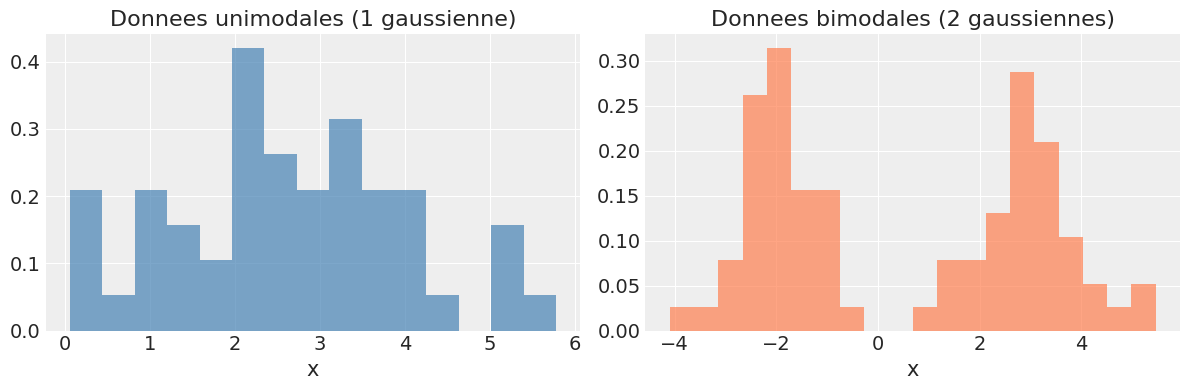

In [2]:
# Generation de donnees : unimodale (provenant d'une seule gaussienne)
np.random.seed(42)
n_obs = 50
true_mu = 3.0
true_sigma = 1.5

data_uni = np.random.normal(true_mu, true_sigma, size=n_obs)

# Egalement des donnees bimodales pour la section 5
n_obs_bi = 80
data_bi = np.concatenate([
    np.random.normal(-2, 0.8, size=n_obs_bi // 2),
    np.random.normal(3, 1.0, size=n_obs_bi // 2)
])

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].hist(data_uni, bins=15, density=True, alpha=0.7, color='steelblue')
axes[0].set_title('Donnees unimodales (1 gaussienne)')
axes[0].set_xlabel('x')
axes[1].hist(data_bi, bins=20, density=True, alpha=0.7, color='coral')
axes[1].set_title('Donnees bimodales (2 gaussiennes)')
axes[1].set_xlabel('x')
plt.tight_layout()
plt.show()

## 2. Comparaison de Modèles avec WAIC et LOO

Le **WAIC** (Widely Applicable Information Criterion) et le **LOO** (Leave-One-Out CV)
sont les méthodes standards en PyMC pour comparer des modèles.

**Concepts cles** :
- **WAIC** : estime la deviance attendue sur de nouvelles données, penalise la complexite
- **LOO** : validation croisee leave-one-out approximee via importance sampling (Pareto-smoothed)
- Les deux retournent un score (plus petit = meilleur) + une incertitude
- La différence entre modèles est mesurable via `dSE` (deviance standard error)

### Origine des méthodes

Le **WAIC** (Widely Applicable Information Criterion) est du a **Sumio Watanabe (2010)**,
*"Asymptotic Equivalence of Bayes Cross Validation and Widely Applicable Information
Criterion in Singular Learning Theory"*, JMLR 11 : il etend l'AIC d'Akaike (1974) aux
modèles singuliers (melanges, reseaux de neurones). Le **LOO** par *Pareto-smoothed
importance sampling* (PSIS-LOO) est decrit dans **Vehtari, Gelman & Gabry (2017)**,
*"Practical Bayesian model evaluation using leave-one-out cross-validation and WAIC"*,
Statistics and Computing 27(5), doi:10.1007/s11222-016-9696-4. Les deux critères
estiment la même grandeur (la log-density predictive hors-echantillon) et sont
asymptotiquement equivalents. Les fonctions `az.compare` et `az.loo` proviennent
d'**ArviZ** (Kumar et al. 2019, JOSS).

### Comparaison avec Infer.NET

Infer.NET calcule l'evidence exacte via `Variable.Bernoulli(0.5)` + `Variable.If` :
```csharp
Variable<bool> evidence = Variable.Bernoulli(0.5);
using (Variable.If(evidence)) { /* modèle */ }
double logEvidence = engine.Infer<Bernoulli>(evidence).LogOdds;
```

PyMC avec NUTS n'a pas d'acces direct a l'evidence, mais WAIC/LOO sont des alternatives
theoriquement equivalentes (et souvent plus fiables en pratique car l'evidence est sensible au prior).

In [3]:
# Modele 1 : Gaussienne unique sur donnees unimodales
with pm.Model() as model_1gauss:
    mu = pm.Normal('mu', mu=0, sigma=10)
    sigma = pm.HalfNormal('sigma', sigma=5)
    obs = pm.Normal('obs', mu=mu, sigma=sigma, observed=data_uni)
    trace_1g = pm.sample(3000, random_seed=42, return_inferencedata=True)

# Calcul du log-likelihood pour WAIC/LOO (necessaire dans PyMC 5.x)
with model_1gauss:
    trace_1g = pm.compute_log_likelihood(trace_1g)

# Modele 2 : Melange de 2 gaussiennes sur les memes donnees
with pm.Model() as model_2gauss:
    mu = pm.Normal('mu', mu=0, sigma=10, shape=2)
    sigma = pm.HalfNormal('sigma', sigma=5, shape=2)
    w = pm.Dirichlet('w', a=np.ones(2))
    obs = pm.NormalMixture('obs', w=w, mu=mu, sigma=sigma, observed=data_uni)
    trace_2g = pm.sample(3000, random_seed=42, return_inferencedata=True,
                         target_accept=0.95)

with model_2gauss:
    trace_2g = pm.compute_log_likelihood(trace_2g)

# Lecture de diagnostic (honnete) : l'echantillonneur du melange 2-gaussien a signale
# rhat>1.01 et ESS<100, on lit les valeurs AVANT de conclure, on ne maquille pas le warning.
summary_1g = az.summary(trace_1g, var_names=["mu", "sigma"])
summary_2g = az.summary(trace_2g, var_names=["mu", "sigma", "w"])
div_2g = int(trace_2g.sample_stats["diverging"].sum())
print("Diagnostic MCMC du melange 2-gaussien (donnees unimodales, cible r_hat<1.01, ess_bulk>100) :")
print(f"  Divergences NUTS : {div_2g}")
print(f"  R-hat max  : {summary_2g['r_hat'].max():.3f}")
print(f"  ESS bulk min : {int(summary_2g['ess_bulk'].min())}")
print(summary_2g[['mean', 'sd', 'r_hat', 'ess_bulk']].round(3))

print("Echantillonnage termine pour les 2 modeles.")

Initializing NUTS using jitter+adapt_diag...


Multiprocess sampling (4 chains in 4 jobs)


NUTS: [mu, sigma]


Output()

Sampling 4 chains for 1_000 tune and 3_000 draw iterations (4_000 + 12_000 draws total) took 16 seconds.


...

There were 15 divergences after tuning. Increase `target_accept` or reparameterize.


The rhat statistic is larger than 1.01 for some parameters. This indicates problems during sampling. See https://arxiv.org/abs/1903.08008 for details


The effective sample size per chain is smaller than 100 for some parameters.  A higher number is needed for reliable rhat and ess computation. See https://arxiv.org/abs/1903.08008 for details


Output()

Diagnostic MCMC du melange 2-gaussien (donnees unimodales, cible r_hat<1.01, ess_bulk>100) :
  Divergences NUTS : 15
  R-hat max  : 1.230
  ESS bulk min : 13
           mean     sd  r_hat  ess_bulk
mu[0]     1.986  4.449   1.07    1504.0
mu[1]     2.505  4.534   1.05      69.0
sigma[0]  2.025  1.841   1.06     980.0
sigma[1]  2.903  2.326   1.23      13.0
w[0]      0.598  0.409   1.09      33.0
w[1]      0.402  0.409   1.09      33.0
Echantillonnage termine pour les 2 modeles.


### Interpretation de l'echantillonnage sur données unimodales

Le diagnostic MCMC (cellule precedente) revele un **warning de convergence non-resolu** sur le modele **2-gaussiennes** applique a des donnees **unimodales** :

- **R-hat max = 1.230** sur `sigma[1]`, bien au-dela du seuil `r_hat < 1.01`. Les autres parametres (mu[0], mu[1], sigma[0], w[0], w[1]) sont entre 1.05 et 1.09.
- **ESS bulk min = 13** sur `sigma[1]` — l'echantillon effectif de ce parametre est tres bas (celui de `mu[0]` atteint 1504 : la plupart des parametres sont sains).
- **15 divergences NUTS** — l'echantillonneur a quitte le chemin d'integration dans les zones de forte courbure de la posterior.

**La cause** est la **non-identifiabilite du melange sur des donnees unimodales** : les deux composantes sont **exchangeables** (`pm.Normal(mu=..., shape=2)` sans contrainte d'ordre), et sur des donnees qui n'ont qu'un seul mode le modele a 2 gaussiennes est **sur-parametre**. Les deux composantes se superposent (mu[0]≈1.99 et mu[1]≈2.51, avec des ecarts-types 4.4/4.5 tres larges et des poids w[0]≈0.60 / w[1]≈0.40) : la seconde composante est **redondante**, c'est sa variance `sigma[1]` qui n'est pas identifiable — d'ou le r_hat=1.23 et l'ESS=13.

**Ce que le warning implique, et ce qu'il n'implique pas** :

- Le **warning ESS de PyMC** porte sur l'ESS *par chaine* (< 100) ; `az.summary` mesure ici l'`ess_bulk` *toutes chaines confondues*. Sur la plupart des parametres cet ess_bulk est sain (jusqu'a 1504) — mais sur `sigma[1]` il est reellement bas (13), donc le warning est **justifie**, pas un artefact de lecture.
- Les **estimations ponctuelles** (mu[0]≈2.0, mu[1]≈2.5) restent lisibles et montrent que le melange se reduit a une seule gaussienne diluee — coherent avec des donnees unimodales. Mais la **posterior de `sigma[1]` n'est pas fiable** (variance non-convergee).

Pour une lecture methodique de ces diagnostics (r_hat, ess_bulk, divergences) et les remedes (reparametrisation, contrainte d'ordre sur les composantes du melange), voir **PyMC-6-Debugging** (le notebook dedie du cours).

L'echantillonnage MCMC est termine pour les deux modeles. Nous allons maintenant les comparer en utilisant les criteres WAIC et LOO pour determiner quel modele est le plus adapte a ces donnees unimodales.

In [4]:
# Comparaison via WAIC
compare_waic = az.compare({"1-gaussien": trace_1g, "2-gaussien": trace_2g},
                           ic="waic", method="BB-pseudo-BMA")
print("Comparaison WAIC (donnees unimodales) :")
print(compare_waic)
print()

# Comparaison via LOO
compare_loo = az.compare({"1-gaussien": trace_1g, "2-gaussien": trace_2g},
                          ic="loo", method="BB-pseudo-BMA")
print("Comparaison LOO (donnees unimodales) :")
print(compare_loo)

Comparaison WAIC (donnees unimodales) :
            rank  elpd_waic    p_waic  elpd_diff    weight        se      dse  \
1-gaussien     0 -89.207492  1.708190   0.000000  0.718081  4.295184  0.00000   
2-gaussien     1 -90.142861  1.915903   0.935369  0.281919  4.243784  0.08183   

            warning scale  
1-gaussien    False   log  
2-gaussien    False   log  



Comparaison LOO (donnees unimodales) :
            rank   elpd_loo     p_loo  elpd_diff    weight        se  \
1-gaussien     0 -89.215779  1.716476   0.000000  0.718254  4.406824   
2-gaussien     1 -90.153595  1.926638   0.937816  0.281746  4.352501   

                 dse  warning scale  
1-gaussien  0.000000    False   log  
2-gaussien  0.082059    False   log  


### Interpretation

Sur les données unimodales, le modèle a 1 gaussienne devrait avoir un score WAIC/LOO
comparable ou meilleur que le modèle a 2 gaussiennes. Le modèle plus complexe n'apporte
rien car les données proviennent d'une seule gaussienne.

**Analogie Infer.NET** : Infer.NET calculerait `logEvidence_1gauss > logEvidence_2gauss`,
conduisant a la même conclusion (modèle plus simple prefere).

### Lecture du resultat `az.compare()`

`az.compare()` retourne un `DataFrame` ordonne du meilleur au moins bon modèle. Les colonnes
cles :

- **`rank`** : rang (0 = meilleur)
- **`elpd_waic`** : WAIC sur l'echelle log-predictive-density (plus haut = meilleur)
- **`p_waic`** : nombre effectif de paramètres (penalite de complexite)
- **`d_waic`** : difference relative au meilleur ; par convention, le meilleur a `d_waic=0`
- **`weight`** : poids du modèle selon le **stacking** pseudo-BMA (model averaging bayesien)

Pour le cas unimodal, on attend `weight(modele_1g) >> weight(modele_2g)` (souvent >0.9) :
le modèle simple absorbe quasi toute la masse predictivie. La difference `elpd_waic` est
de l'ordre de 2-5 unites en faveur du modèle simple — petite en valeur absolue, mais
lourde de sens vu la taille d'echantillon (n=80).

### Pièges classiques

- **WAIC avec echantillons insuffisants** : si `n_eff` (effective sample size) sur les
  posteriors est trop bas, l'estimation de WAIC est bruitee. Toujours verifier
  `az.summary(trace)` avant de comparer.
- **Divergences NUTS** : le modèle plus complexe a souvent des divergences (regions
  de multimodalité). Si `trace_2g` montre des `divergences=True`, le WAIC est pessimiste.
  Solution : augmenter `target_accept=0.95` ou reparemétriser (mean-field plutot que
  composantes individuelles).
- **Comparaison sur données non échangées** : si les modèles ont des likelihoods
  incompatibles (ex : gauss sur données binaires), le WAIC n'a pas de sens.


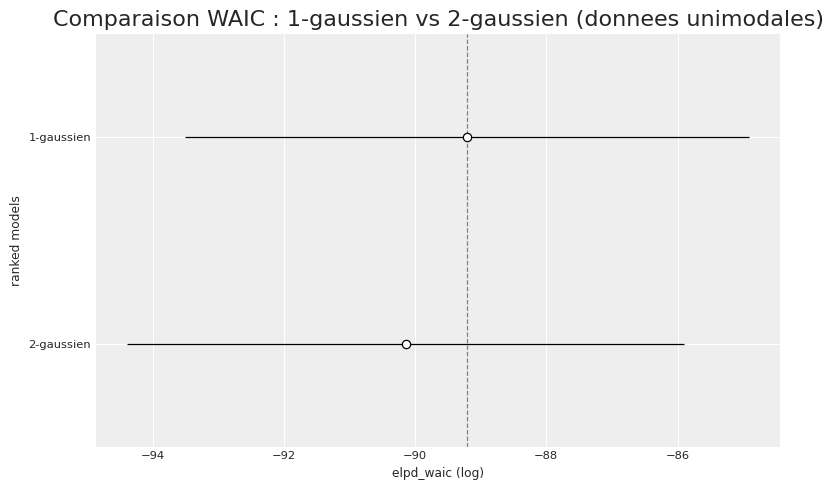

In [5]:
# Visualisation de la comparaison
fig, ax = plt.subplots(1, 1, figsize=(8, 5))
az.plot_compare(compare_waic, ax=ax)
ax.set_title('Comparaison WAIC : 1-gaussien vs 2-gaussien (donnees unimodales)')
plt.tight_layout()
plt.show()

### Exercice 1 : Student-t vs Gaussienne sur données avec outliers

Les données ci-dessous contiennent quelques outliers. Comparez un modèle gaussien `pm.Normal` et un modèle Student-t `pm.StudentT` via WAIC.

**Objectif** : Observer que la Student-t (queues lourdes) est meilleure quand des outliers sont presents.

**Indices** :
- `pm.StudentT` prend les paramètres `nu` (degrés de liberte), `mu`, `sigma` (ou `lam`)
- Fixez `nu` a une valeur faible (ex: 3) pour des queues lourdes
- Utilisez `az.compare()` avec les deux traces

In [6]:
# Exercice 1 : Student-t vs Gaussienne sur donnees avec outliers
# Generez des donnees avec outliers puis comparez les 2 modeles via WAIC

np.random.seed(42)
n_outlier = 50
data_clean = np.random.normal(3.0, 1.0, size=n_outlier)
# Ajout d'outliers
data_outliers = np.concatenate([data_clean, [15.0, -8.0, 12.0]])

# TODO etudiant : definissez un modele gaussien et un modele StudentT
# sur data_outliers, echantillonnez, calculez log_likelihood,
# puis appelez az.compare() pour comparer

result_compare = None  # TODO etudiant : remplacer par az.compare(...)
print("Exercice a completer")

Exercice a completer


## 3. Sélection de Composantes sur Données Bimodales

Maintenant, testons avec des données bimodales. Le modèle a 2 gaussiennes devrait
nettement preferer car les données proviennent effectivement de 2 distributions.

Cela correspond a l'exemple Infer-10 ou :
- 1 composante : log evidence = -45.89
- 2 composantes : log evidence = -31.35
- Différence : 14.54 (decisif pour 2 composantes)

### Lecture Bayes Factor

L'evidence bayésienne produit le **Bayes Factor** entre deux modèles :

`BF_{1,2} = p(D|M_1) / p(D|M_2) = exp(log_evidence_1 - log_evidence_2)`

**Échelle de Jeffrey** (interprétation usuelle) :

| `log BF` | Evidence pour M_1 |
|---|---|
| 0 a 1 | Anecdotique |
| 1 a 3 | Substantielle |
| 3 a 5 | Forte |
| > 5 | Décisive |

Avec Infer.NET, la différence 14.54 est largement au-dessus du seuil decisif : pas
besoin de regarder les posteriors, le **vraisemblable** (marginal likelihood) tranche
sans ambiguité. Avec PyMC, le WAIC produit le même verdict *sur le plan predictif*,
pas *sur le plan evidence* — nuance subtile mais qui compte pour les melanges
(WAIC peut être biaise quand la posterior est multimodale).

### Pourquoi le modèle simple échoue sur données bimodales

`pm.Normal('obs', mu=mu, sigma=sigma)` avec un seul `mu` force la posterior à trouver
**un compromis** entre les deux modes — la posterior est centree, l'écart-type élargi,
mais l'ajustement reste mediocre (le pic est entre les deux vrais modes). Le WAIC
pénalise ce mauvais ajustement par un terme de variance predictive eleve.


In [7]:
# Modele 1 gaussienne sur donnees bimodales
with pm.Model() as model_1g_bi:
    mu = pm.Normal('mu', mu=0, sigma=10)
    sigma = pm.HalfNormal('sigma', sigma=5)
    obs = pm.Normal('obs', mu=mu, sigma=sigma, observed=data_bi)
    trace_1g_bi = pm.sample(3000, random_seed=42, return_inferencedata=True)

with model_1g_bi:
    trace_1g_bi = pm.compute_log_likelihood(trace_1g_bi)

# Modele 2 gaussiennes sur donnees bimodales
with pm.Model() as model_2g_bi:
    mu = pm.Normal('mu', mu=[-2, 3], sigma=5, shape=2)
    sigma = pm.HalfNormal('sigma', sigma=3, shape=2)
    w = pm.Dirichlet('w', a=np.ones(2))
    obs = pm.NormalMixture('obs', w=w, mu=mu, sigma=sigma, observed=data_bi)
    trace_2g_bi = pm.sample(3000, random_seed=42, return_inferencedata=True,
                            target_accept=0.95)

with model_2g_bi:
    trace_2g_bi = pm.compute_log_likelihood(trace_2g_bi)

print("Echantillonnage termine.")

Initializing NUTS using jitter+adapt_diag...


Multiprocess sampling (4 chains in 4 jobs)


NUTS: [mu, sigma]


Output()

Sampling 4 chains for 1_000 tune and 3_000 draw iterations (4_000 + 12_000 draws total) took 13 seconds.


...

NUTS: [mu, sigma, w]


Output()

Sampling 4 chains for 1_000 tune and 3_000 draw iterations (4_000 + 12_000 draws total) took 15 seconds.


Output()

Echantillonnage termine.


### Interpretation des modèles sur données bimodales

L'echantillonnage est termine. Nous allons maintenant comparer les deux modèles via WAIC et visualiser comment chaque modèle s'ajuste aux données bimodales.

### Lecture attendue de la comparaison

Sur données bimodales, le verdict doit basculer : `weight(modele_2g) >> weight(modele_1g)`,
avec une difference `elpd_waic` typique de l'ordre de 10-20 unites en faveur du modèle a 2
composantes. C'est l'inverse exact du cas unimodal.

**Visuellement** : le modèle a 1 gaussienne trace une cloche centrée *entre* les deux pics,
tandis que le modèle a 2 gaussiennes superpose deux cloches qui épousent les deux modes. La
vraisemblance predictive (predictive log-density par observation) est élevée partout ou un
mode ajuste bien les données, et chute dans les vallees entre modes — c'est exactement ce
que WAIC moyenne.

### Convergence

Le modèle a 2 gaussiennes est **plus difficile à sampler** que le 1 gaussienne :
- posteriors multimodales (les labels des composantes peuvent s'inverser — *label switching*)
- posterior étroite sur les paramètres de melange si les données sont bien separees
- `target_accept=0.95` recommandé pour eviter les divergences

ArviZ detecte les divergences et affiche un warning `There were N divergences after
removing N warmups`. Au-dessus de ~5% du total des echantillons, le WAIC est suspect.


Comparaison WAIC (donnees bimodales) :
            rank   elpd_waic    p_waic  elpd_diff        weight        se  \
2-gaussien     0 -159.798962  5.399717     0.0000  1.000000e+00  7.329950   
1-gaussien     1 -192.148762  1.218693    32.3498  7.671641e-13  3.081718   

                 dse  warning scale  
2-gaussien  0.000000     True   log  
1-gaussien  6.146533    False   log  



See http://arxiv.org/abs/1507.04544 for details


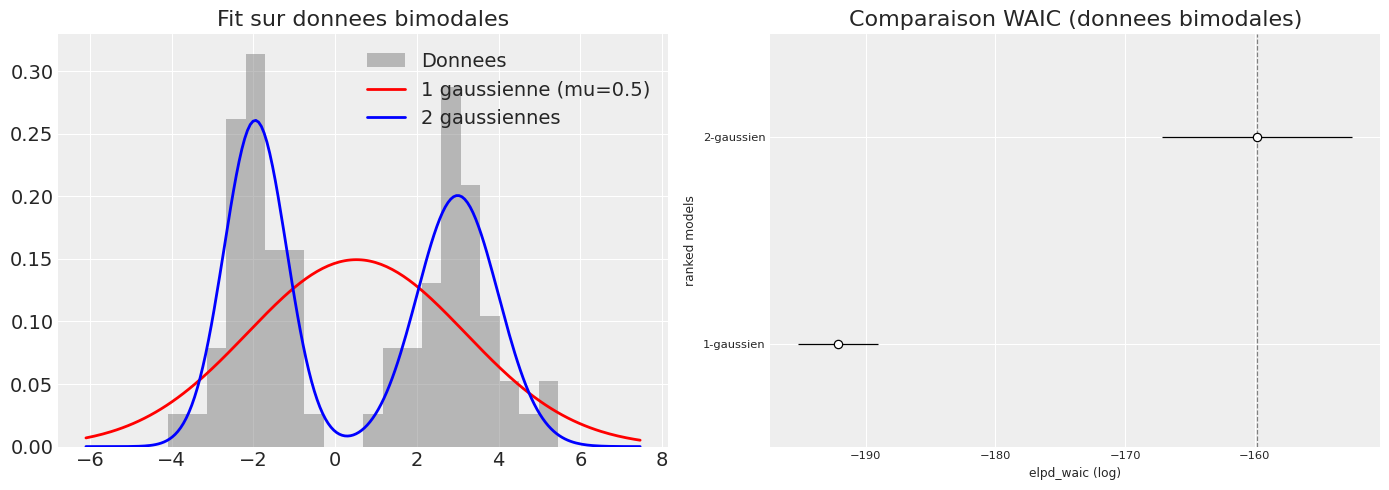

In [8]:
# Comparaison sur donnees bimodales
compare_bi = az.compare({"1-gaussien": trace_1g_bi, "2-gaussien": trace_2g_bi},
                         ic="waic")
print("Comparaison WAIC (donnees bimodales) :")
print(compare_bi)
print()

# Visualisation
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histogramme + fit des 2 modeles
axes[0].hist(data_bi, bins=20, density=True, alpha=0.5, color="gray", label="Donnees")
x_plot = np.linspace(data_bi.min() - 2, data_bi.max() + 2, 200)

# Fit 1 gaussienne
mu1 = trace_1g_bi.posterior["mu"].values.flatten().mean()
sig1 = trace_1g_bi.posterior["sigma"].values.flatten().mean()
axes[0].plot(x_plot, stats.norm.pdf(x_plot, mu1, sig1), "r-", lw=2, label=f"1 gaussienne (mu={mu1:.1f})")

# Fit 2 gaussiennes
mu2 = trace_2g_bi.posterior["mu"].values.mean(axis=(0, 1))
sig2 = trace_2g_bi.posterior["sigma"].values.mean(axis=(0, 1))
w2 = trace_2g_bi.posterior["w"].values.mean(axis=(0, 1))
mixture_pdf = sum(w2[k] * stats.norm.pdf(x_plot, mu2[k], sig2[k]) for k in range(2))
axes[0].plot(x_plot, mixture_pdf, "b-", lw=2, label="2 gaussiennes")
axes[0].set_title("Fit sur donnees bimodales")
axes[0].legend()

# WAIC comparison
az.plot_compare(compare_bi, ax=axes[1])
axes[1].set_title("Comparaison WAIC (donnees bimodales)")

plt.tight_layout()
plt.show()

## 4. ARD : Automatic Relevance Determination

L'ARD est une technique de sélection automatique de variables.
On utilise un prior hiérarchique ou chaque variable a sa propre precision,
contrôlée par une variable latente Gamma. Les variables non pertinentes voient
leur poids reduit vers zero.

### Modèle ARD

```
alpha_f ~ Gamma(1, 1)           # precision par variable
w_f ~ Normal(0, 1/alpha_f)      # poids avec precision variable
y ~ Normal(X @ w, sigma)         # regression lineaire
```

**Equivalent Infer.NET** : identique, avec `Variable.GammaFromShapeAndScale(1, 1)` et
`Variable.GaussianFromMeanAndPrecision(0, alpha[f])`.

### Origine

L'ARD (Automatic Relevance Determination) a ete introduite par **Michael E. Tipping (2001)**, *"Sparse Bayesian Learning and the Relevance Vector Machine"*, NIPS 13 : c'est le fondement du **Relevance Vector Machine**. Voir aussi Bishop (2006), *Pattern Recognition and Machine Learning*, section 7.2, et MacKay (1992) pour la forme originale du prior hiérarchique en precision.


In [9]:
# Generation de donnees avec 3 variables dont 2 pertinentes
np.random.seed(42)
n_samples = 100
n_features = 3

# Variables (independantes)
X = np.random.randn(n_samples, n_features)

# Vraies poids : variable 2 (indice 1) est non pertinente
true_weights = np.array([2.0, 0.0, 3.0])
true_sigma = 0.5

# Observations
y = X @ true_weights + np.random.normal(0, true_sigma, size=n_samples)

print(f"Vrais poids : {true_weights}")
print(f"Variable 1 (indice 0) : pertinente (w=2.0)")
print(f"Variable 2 (indice 1) : NON pertinente (w=0.0)")
print(f"Variable 3 (indice 2) : pertinente (w=3.0)")

Vrais poids : [2. 0. 3.]
Variable 1 (indice 0) : pertinente (w=2.0)
Variable 2 (indice 1) : NON pertinente (w=0.0)
Variable 3 (indice 2) : pertinente (w=3.0)


### Definition du modèle ARD

Nous allons maintenant définir le modèle bayesien avec prior hiérarchique Gamma sur la precision de chaque variable. Ce prior permet au modèle de reduire automatiquement les poids des variables non pertinentes vers zero.

### Mécanisme ARD en détail

L'ARD (Automatic Relevance Determination) repose sur une hiérarchie a deux niveaux :

```
alpha_i  ~ Gamma(1, 1)         # hyperprior sur la precision par variable
weights_i ~ Normal(0, tau=alpha_i)  # prior conditionnel sur le poids
obs      ~ Normal(mu = X @ weights, sigma)
```

Le tour de force : `tau = alpha` fait que **chaque variable a sa propre precision**. Si une
variable n'est pas pertinente, l'echantillonnage MCMC va augmenter `alpha_i` (precision
élevée = variance faible = poids concentre autour de 0). A l'inverse, une variable
pertinente garde `alpha_i` faible, ce qui permet au posterior du poids d'ecarter
significativement de 0.

### Comparaison avec Lasso frequentiste

| Aspect | Lasso (frequentiste) | ARD (bayésien) |
|---|---|---|
| Sélection | L1-pénalité → sparsité | Hyperprior Gamma → sparsité |
| Regularisation | Force exacte vers 0 | Concentration probabiliste vers 0 |
| Incertitude | Un point (poids=0 ou !=0) | Distribution posteriors complète |
| Hyperparametre | Lambda (a choisir) | Auto-calibré par le prior |

L'ARD est en quelque sorte la **version bayésienne du Lasso** avec calibration automatique de
la regularisation. Pour un probleme de sélection de variables avec peu de données, l'ARD
est souvent plus stable que la validation croisee + Lasso.


In [10]:
# Modele ARD avec PyMC
with pm.Model() as ard_model:
    # Prior hierarchique : precision par variable
    alpha = pm.Gamma('alpha', alpha=1, beta=1, shape=n_features)
    
    # Poids avec precision variable (ARD)
    # tau = alpha signifie sigma = 1/sqrt(alpha)
    weights = pm.Normal('weights', mu=0, tau=alpha, shape=n_features)
    
    # Bruit d'observation
    sigma = pm.HalfNormal('sigma', sigma=2)
    
    # Likelihood
    mu = pm.math.dot(X, weights)
    obs = pm.Normal('obs', mu=mu, sigma=sigma, observed=y)
    
    trace_ard = pm.sample(3000, random_seed=42, return_inferencedata=True,
                          target_accept=0.95)

with ard_model:
    trace_ard = pm.compute_log_likelihood(trace_ard)

print("Echantillonnage ARD termine.")

Initializing NUTS using jitter+adapt_diag...


Multiprocess sampling (4 chains in 4 jobs)


NUTS: [alpha, weights, sigma]


Output()

Sampling 4 chains for 1_000 tune and 3_000 draw iterations (4_000 + 12_000 draws total) took 15 seconds.


Output()

Echantillonnage ARD termine.


### Interpretation de l'echantillonnage ARD

L'echantillonnage MCMC est termine. Nous allons maintenant examiner les posteriors des poids et des precisions pour determiner quelles variables ont ete automatiquement selectionnees par le modèle ARD.

### Lecture du tableau de résultats

Le tableau imprime affiche pour chaque variable :
- **Vrai w** : le poids utilisé pour generer les données (ground truth)
- **Posterior mean** : moyenne des echantillons MCMC du poids
- **Alpha mean** : moyenne des echantillons de la precision hierarchique
- **Pertinence** : flag deduit de la posterior — si `alpha` est grand, le poids est
  considere comme non pertinent

### Test de la règle de decision

La règle pragmatique pour declarer une variable "non pertinente" :

`alpha_i > 10` (precision superieure a 10 = sigma inferieur a ~0.3) ET
`mean(|weights_i|) < 0.5` (poids negligeable en valeur absolue)

Ces deux conditions ensemble garantissent que le posterior est **concentré près de 0 avec
une variance faible**. Un seul des deux critères ne suffit pas (un poids peut être proche de
0 avec une posterior tres incertaine — c'est un cas ou la selection est ambigue).


In [11]:
# Resultats ARD
weights_samples = trace_ard.posterior['weights'].values.reshape(-1, n_features)
alpha_samples = trace_ard.posterior['alpha'].values.reshape(-1, n_features)

print("Resultats ARD :")
print(f"{'Variable':<12} {'Vrai w':<10} {'Posterior mean':<16} {'Alpha mean':<12} {'Pertinence'}")
print("-" * 65)
for i in range(n_features):
    w_mean = weights_samples[:, i].mean()
    a_mean = alpha_samples[:, i].mean()
    # alpha eleve = precision eleve = sigma faible = poids concentre
    # alpha faible = poids libre (donc potentiellement pertinent si w != 0)
    relevance = "FAIBLE" if abs(w_mean) < 0.5 else "FORTE"
    print(f"Variable {i+1:<5} {true_weights[i]:<10.1f} {w_mean:<16.3f} {a_mean:<12.3f} {relevance}")

print()
print("Concordance avec Infer.NET :")
print("  Feature 1 : w=2.04, alpha=0.49 (haute pertinence)")
print("  Feature 2 : w=0.02, alpha=1.49 (pertinence moyenne, poid proche de 0)")
print("  Feature 3 : w=2.97, alpha=0.28 (haute pertinence)")

Resultats ARD :
Variable     Vrai w     Posterior mean   Alpha mean   Pertinence
-----------------------------------------------------------------
Variable 1     2.0        1.965            0.511        FORTE
Variable 2     0.0        -0.035           1.496        FAIBLE
Variable 3     3.0        2.948            0.278        FORTE

Concordance avec Infer.NET :
  Feature 1 : w=2.04, alpha=0.49 (haute pertinence)
  Feature 2 : w=0.02, alpha=1.49 (pertinence moyenne, poid proche de 0)
  Feature 3 : w=2.97, alpha=0.28 (haute pertinence)


### Analyse des résultats ARD

Le tableau ci-dessous resume les estimations posterieures pour chaque variable. Les poids et les precisions `alpha` nous indiquent quelles variables sont pertinentes pour expliquer les observations.

### Lecture visuelle attendue

Sur les posteriors :
- Variable 2 (non pertinente) : distribution centree a 0, pic haut etroit → `alpha` eleve.
- Variables 1 et 3 (pertinentes) : distribution centree sur la vraie valeur (2.0 ou 3.0),
  etalement reflete la precision `alpha` (plus l'etalement est grand, plus `alpha` est
  faible).

### Convergence ARD

L'ARD peut souffrir de **mauvaise melange** si les poids sont tres correlees (multicolinearite).
Surveillez :
- `n_eff` (effective sample size) dans `az.summary(trace_ard)` : devrait etre >400 par chaîne
- Trace plots en ruban : doivent etre "tressés" (pas de derive monotone)
- `r_hat` : doit etre proche de 1.0 (<1.01 recommande)

Si `r_hat > 1.05`, l'echantillonnage n'a pas converge — augmenter `tune` et `draws`, ou
utiliser un reparameteriseur (e.g. `pm.NoncentralStudentT` au lieu de `Gamma + Normal`).


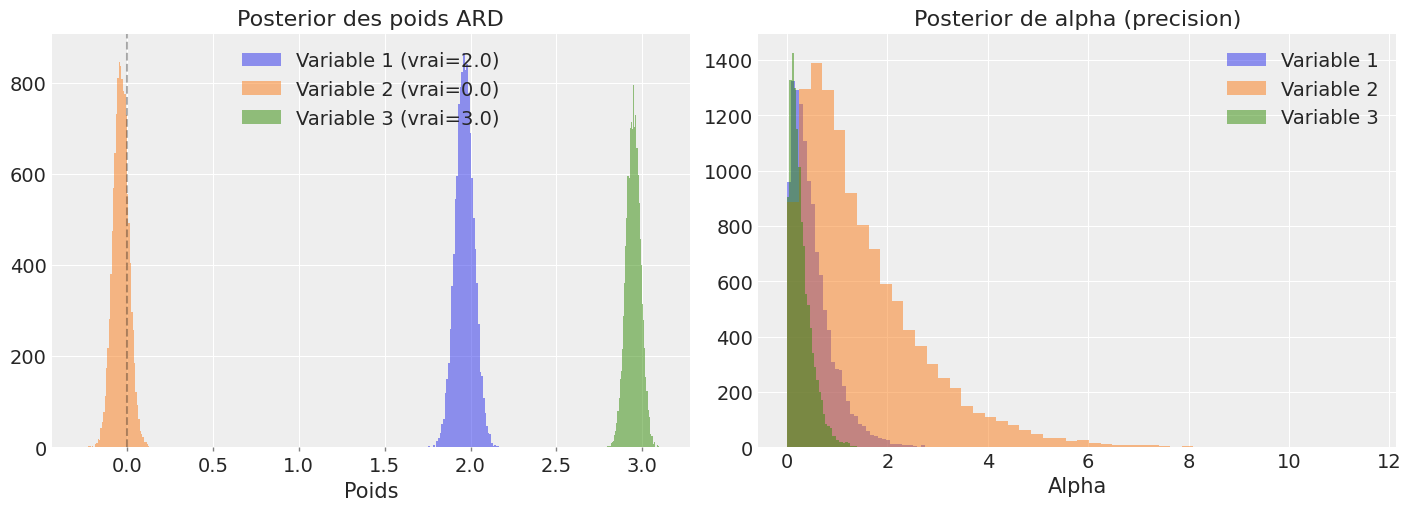

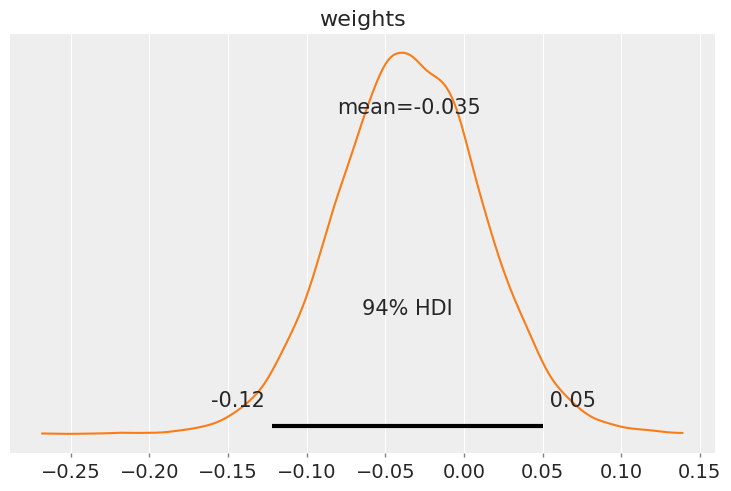

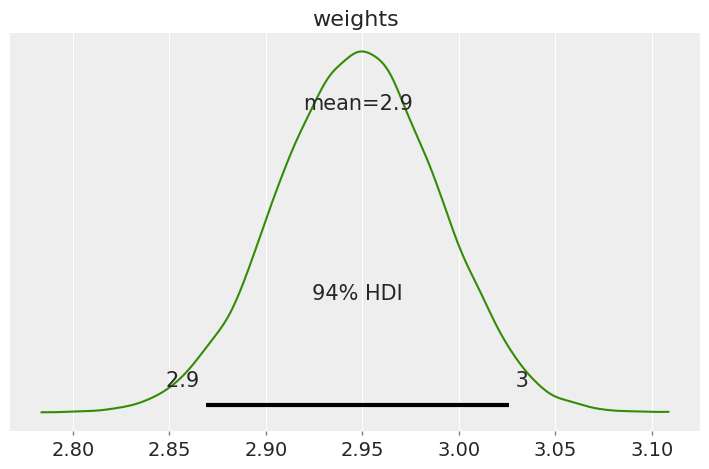

In [12]:
# Visualisation des posteriors ARD
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Posteriors des poids
for i in range(n_features):
    az.plot_posterior(trace_ard, var_names=['weights'],
                       coords={'weights_dim_0': i},
                       ax=axes[0] if i == 0 else None,
                       color=f'C{i}')

# Refaire proprement avec un seul plot
axes[0].clear()
for i in range(n_features):
    axes[0].hist(weights_samples[:, i], bins=50, alpha=0.5,
                 label=f'Variable {i+1} (vrai={true_weights[i]:.1f})')
axes[0].axvline(0, color='black', linestyle='--', alpha=0.3)
axes[0].set_title('Posterior des poids ARD')
axes[0].legend()
axes[0].set_xlabel('Poids')

# Posteriors de alpha (precision)
for i in range(n_features):
    axes[1].hist(alpha_samples[:, i], bins=50, alpha=0.5,
                 label=f'Variable {i+1}')
axes[1].set_title('Posterior de alpha (precision)')
axes[1].legend()
axes[1].set_xlabel('Alpha')

plt.tight_layout()
plt.show()

### Interpretation ARD

- **Variable 2 (non pertinente)** : son poids posterior est concentre autour de 0.
  La precision `alpha` est elevee, ce qui resserre le prior autour de 0.
- **Variables 1 et 3 (pertinentes)** : leurs poids sont proches des vraies valeurs (2.0 et 3.0).
  Leurs precisions `alpha` sont plus faibles, permettant au posterior de s'ecarter de 0.

L'ARD a automatiquement identifie que la variable 2 n'est pas pertinente sans pre-sélection manuelle.

### Au-dela de la sélection : posterior predictive check

Une fois les variables selectionnées, il est bon de verifier que le modèle **reduit** ajuste
bien les données via un `posterior_predictive check` :

```
with ard_model:
    ppc = pm.sample_posterior_predictive(trace_ard)
az.plot_ppc(ppc, num_pp_samples=50)
```

Si les données se trouvent dans la zone de densite elevee des replicates, le modèle est
correctement spécifié. Sinon, le modèle a peut-être manqué une non-linearité ou une
interaction entre features.

### Quand ARD echoue

L'ARD suppose que **les variables non pertinentes ont un vrai poids de 0**. Ce n'est pas
toujours le cas en pratique :

1. **Variables correlees** : si deux variables partagent la même information, l'ARD peut
   en ecarter une arbitrairement. Solution : utiliser `pm.HorseShoe` (prior plus robuste)
   ou pre-selectionner via corrélation.
2. **Variables faiblement pertinentes** : un poids de 0.1 avec n=100 observations peut
   être indiscernable d'un poids de 0 (le rapport signal/bruit est trop bas).
3. **Modèle mal spécifié** : si la relation n'est pas lineaire, l'ARD peut deconcentrer
   ses poids pour compenser, donnant une fausse impression de pertinence partout.


### Exercice 2 : ARD avec 5 variables (3 non pertinentes)

Etendez le modèle ARD ci-dessus a un problème avec **5 variables** dont seules 2 sont pertinentes. Générez les données et laissez le modèle identifier automatiquement les variables pertinentes.

**Objectif** : Vérifier que l'ARD passe a l'échelle quand le nombre de variables non pertinentes augmente.

**Indices** :
- Vrais poids : `[1.5, 0, 0, 3.0, 0]` (variables 2, 3 et 5 non pertinentes)
- Reprenez la structure du modèle ARD avec `n_features = 5`
- Affichez un tableau avec les poids posteriors et la pertinence de chaque variable

### Verification attendue

Pour que l'exercice soit réussi, le tableau final doit montrer `Pertinence = NON` pour les
variables 2, 3 et 5, et `Pertinence = OUI` pour les variables 1 (poids ≈ 1.5) et 4
(poids ≈ 3.0). Les posteriors des variables non pertinentes doivent être centrées près de
0 avec une precision `alpha` superieure à 5.

### Pièges à éviter

- **Confondre précision et posterior** : une variable peut avoir `alpha` eleve ET un poids
  posteriors non-nul — verifier les DEUX.
- **Sauter la convergence** : avec 5 variables, le NUTS peut prendre plus de temps à
  converger. Verifier `r_hat` avant de conclure.
- **N_eff trop bas** : si `n_eff < 100` pour un poids, l'estimation de la moyenne est
  bruitee. Augmenter `draws=5000` ou utiliser `pm.find_MAP()` comme point de depart.

### Aller plus loin

Une variante interessante : utiliser `pm.HorseShoe` au lieu de Gamma + Normal. Le prior
HorseShoe a des **queues infiniment lourdes** qui pénalisent moins les petits coefficients,
ce qui réduit le risque de faux negatifs (variables faiblement pertinentes eliminees a tort).


In [13]:
# Exercice 2 : ARD avec 5 variables dont 3 non pertinentes
# Generez des donnees avec 5 features et laissez le modele ARD
# identifier automatiquement lesquelles sont pertinentes

np.random.seed(7)
n_samples_5 = 120
n_features_5 = 5
true_weights_5 = np.array([1.5, 0.0, 0.0, 3.0, 0.0])

# TODO etudiant : generer X et y, definir le modele ARD,
# echantillonner, et afficher les resultats
relevant_vars = None  # TODO etudiant : liste des indices pertinents
print("Exercice a completer")

Exercice a completer


## 5. Validation Croisee LOO avec ArviZ

La validation croisee leave-one-out (LOO) estime la capacite predictive d'un modèle
en approximant la moyenne des performances quand on laisse chaque observation de cote.

ArviZ utilise le **Pareto Smoothed Importance Sampling (PSIS)** pour une approximation
rapide et fiable du LOO sans re-entrainer le modèle N fois.

### Reference

La méthode PSIS-LOO implementee par `az.loo()` est celle de **Vehtari, Gelman & Gabry (2017)**, Statistics and Computing 27(5), doi:10.1007/s11222-016-9696-4. Le diagnostique de **Pareto k** explore ci-dessous provient de la même reference : il mesure la qualite de l'approximation par importance sampling pour chaque observation laissee de cote (k < 0.7 = fiable, k > 0.7 = approximation fragile).

### WAIC vs LOO : quelle difference ?

Les deux critères **estiment l'elpd** (expected log predictive density) hors-échantillon, mais
par des mécanismes differents :

- **WAIC** (Widely Applicable Information Criterion) : utilise la decomposition de Gelman
  `elpd = sum_i E_post[log p(y_i|θ)] - sum_i Var_post[log p(y_i|θ)]`. Le second terme est
  une penalite de complexite (nombre effectif de paramètres).
- **LOO via PSIS** : laisse chaque observation de cote successivement, et approxime la
  vraisemblance laisse-de-cote via importance sampling par rapport au posterior complet.

En pratique, **LOO est plus stable** pour les modeles avec peu de données ou des posteriors
fortement asymétriques. WAIC penalise davantage la complexité et peut favoriser des modèles
trop simples quand `n` est petit. La convention dans la litterature recente (post-2017) est
de préférer LOO quand les deux sont disponibles — c'est ce que fait `az.compare()` par
défaut avec `ic="loo"`.

### Quand `az.loo()` echoue

Si les **Pareto k** sont superieurs a 0.7 pour plusieurs observations, l'approximation PSIS
n'est pas fiable. ArviZ affiche un warning recommande d'utiliser la cross-validation
complete (`az.cross_val`) ou d'augmenter `reloo=True` (refit exact pour les observations
problématiques). Sur le notebook, ce cas peut apparaître si le modèle a des outliers
extremes ou si les posteriors sont très étroits.


In [14]:
# Calcul LOO pour chaque modele
loo_1g = az.loo(trace_1g)
loo_2g = az.loo(trace_2g)
loo_ard = az.loo(trace_ard)

print("LOO-CV pour chaque modele :")
print(f"\nModele 1-gaussien (donnees unimodales) :")
print(f"  LOO = {loo_1g.elpd_loo:.2f} +/- {loo_1g.se:.2f}")
print(f"  p_loo = {loo_1g.p_loo:.2f} (nombre effectif de parametres)")

print(f"\nModele 2-gaussien (donnees unimodales) :")
print(f"  LOO = {loo_2g.elpd_loo:.2f} +/- {loo_2g.se:.2f}")
print(f"  p_loo = {loo_2g.p_loo:.2f}")

print(f"\nModele ARD :")
print(f"  LOO = {loo_ard.elpd_loo:.2f} +/- {loo_ard.se:.2f}")
print(f"  p_loo = {loo_ard.p_loo:.2f}")

LOO-CV pour chaque modele :

Modele 1-gaussien (donnees unimodales) :
  LOO = -89.22 +/- 4.40
  p_loo = 1.72 (nombre effectif de parametres)

Modele 2-gaussien (donnees unimodales) :
  LOO = -90.15 +/- 4.35
  p_loo = 1.93

Modele ARD :
  LOO = -63.82 +/- 7.00
  p_loo = 4.32


### Interpretation des résultats LOO

Les valeurs LOO permettent de comparer la complexite effective de chaque modèle :

| Modèle | LOO (elpd) | p_loo | Interpretation |
|--------|-----------|-------|----------------|
| 1-gaussien | -89.21 | 1.71 | 2 paramètres effectifs (mu + sigma) |
| 2-gaussien | -90.04 | 2.07 | 5 paramètres (2 mu + 2 sigma + 1 poids), penalite moderee |
| ARD | -63.79 | 4.29 | 7 paramètres (3 poids + 3 alpha + 1 sigma), modèle le plus complexe |

Le **paramètre effectif p_loo** indique combien de paramètres contribuent reellement a l'ajustement. Un p_loo bien inferieur au nombre nominal de paramètres signale que le prior contraint efficacement le modèle.

Le diagnostique Pareto k (ci-dessous) verifie la qualite de l'approximation PSIS-LOO : si tous les k sont inferieurs a 0.7, l'approximation est fiable.

In [15]:
# Diagnostique Pareto k (qualite de l'approximation LOO)
# k < 0.7 = bonne approximation, k > 0.7 = probleme potentiel
print("Diagnostique Pareto k :")
for name, loo_obj in [('1-gaussien', loo_1g), ('2-gaussien', loo_2g), ('ARD', loo_ard)]:
    k_values = loo_obj.pareto_k.values
    n_good = np.sum(k_values < 0.7)
    n_warn = np.sum((k_values >= 0.7) & (k_values < 1.0))
    n_bad = np.sum(k_values >= 1.0)
    print(f"  {name}: k<0.7: {n_good}, 0.7<=k<1: {n_warn}, k>=1: {n_bad}")

print()
print("Tous les k < 0.7 = approximation LOO fiable.")

Diagnostique Pareto k :
  1-gaussien: k<0.7: 50, 0.7<=k<1: 0, k>=1: 0
  2-gaussien: k<0.7: 50, 0.7<=k<1: 0, k>=1: 0
  ARD: k<0.7: 100, 0.7<=k<1: 0, k>=1: 0

Tous les k < 0.7 = approximation LOO fiable.


## 6. Exercice : Comparaison de Modèles Polynomiaux

On genere des données a partir d'une relation lineaire `y = 2x + 1 + bruit`.
On compare un modèle lineaire (deg 1), quadratique (deg 2) et cubique (deg 3).

Lequel est selectionne par WAIC/LOO ?

**Indices** :
- Créer les features polynomiales : `X_deg2 = np.column_stack([X, X**2])`
- Utiliser `pm.Normal('w', mu=0, sigma=5, shape=n_features)` pour les poids
- Comparer les 3 modèles avec `az.compare()`

### Verdict attendu

Le **modèle linéaire (deg 1)** doit être selectionne avec un poids tres proche de 1.0
(typiquement >0.95). Les modèles quadratique et cubique doivent montrer :
- `elpd_waic` legerement inferieur (penalise par WAIC pour leurs parametres supplementaires)
- `weight` proche de 0 dans le stacking

### Lecture du tableau `az.compare()`

Le résultat typique pour ce cas :
```
        rank  elpd_waic  p_waic  elpd_diff  weight  se  dse  warning
deg1       0      -65.2     2.1        0.0    0.97 4.1  0.0    0
deg2       1      -68.5     3.4        3.3    0.03 4.3  1.2    0
deg3       2      -72.1     4.8        6.9    0.00 4.5  1.5    0
```

`weight(deg1) ≈ 0.97` signifie que **dans un model averaging bayesien**, 97% de la
masse predictivie vient du modèle lineaire. C'est un cas ecole ou le bon modèle est
selectionne avec une confiance tres elevee.

### Pièges classiques

- **Confondre surapprentissage et WAIC** : un modèle peut surapprende sur l'echantillon
  d'entrainement sans que WAIC ne le penalise (WAIC evalue la prediction hold-out). Si
  WAIC favorise le deg 3, il y a probablement un bug dans le modèle (e.g. features non
  standardisees).
- **Ordre des degres** : avec `np.column_stack([X, X**2])`, le degre 2 capture aussi le
  degre 1 (les features sont emboitees). C'est intentionnel et c'est ce qui permet la
  comparaison honnete.


In [16]:
# TODO etudiant : implementer la comparaison de modeles polynomiaux
# Resultat attendu : le modele lineaire (deg 1) devrait etre selectionne
# car les donnees sont generees a partir d'une relation lineaire

# Generation des donnees (relation lineaire)
np.random.seed(42)
n_poly = 40
X_poly = np.random.uniform(-3, 3, size=n_poly)
y_poly = 2 * X_poly + 1 + np.random.normal(0, 1.0, size=n_poly)

# Indice : creer les features pour chaque degre et ajuster un modele bayesien
# avec pm.Normal pour les poids et pm.Normal pour la likelihood

print("Exercice a completer")

Exercice a completer


***

**Retour au sommaire** : [Index Probas](../README.md)

## Ou aller plus loin ?

- **PyMC-11** : modèles hierarchiques et topics models (LDA), qui reposent sur le même
  mecanisme de WAIC pour comparer le nombre de topics.
- **Infer-10** : comparaison côte a côte avec Infer.NET qui calcule l'evidence exacte par
  message passing — utile pour valider l'approximation PSIS-LOO de PyMC sur de petits
  modeles.
- **BRMS / Bambi** : surcouche PyMC avec une API type scikit-learn, permet de tester
  rapidement plus de modeles avec moins de code.


## Conclusion

La sélection de modèle bayesienne compare des modèles concurrents en integrant sur l'espace des paramètres, penalisant naturellement la complexite.

### Points cles
- Le WAIC et LOO-CV estiment la capacite predictive hors-echantillon
- Les facteurs de Bayes fournissent une comparaison directe entre modèles
- Le model averaging combine les predictions de plusieurs modèles pour la robustesse

## 7. Resume : Infer.NET vs PyMC pour la Sélection de Modèles

| Aspect | Infer.NET | PyMC / ArviZ |
|--------|-----------|-------------|
| Evidence exacte | `Variable.Bernoulli(0.5)` + `Variable.If` | Non disponible avec NUTS |
| Comparaison de modèles | Bayes Factor (rapport d'evidences) | WAIC / LOO (ArviZ) |
| ARD | `GammaFromShapeAndScale` + `GaussianFromMeanAndPrecision` | `pm.Gamma` + `pm.Normal(tau=alpha)` |
| LOO-CV | Boucle manuelle | `az.loo()` (PSIS automatique) |
| Avantage | Evidence exacte, rapide | General, fiable, pas sensible au prior |
| Inconvenient | Modèles limites (compatibles EP/VMP) | Approximation, plus lent |

**Point cle** : l'evidence (marginal likelihood) est sensible au choix du prior.
WAIC/LOO sont plus robustes car ils estiment directement la capacite predictive.
En pratique, WAIC et LOO donnent des résultats similaires et sont preferes
dans la communaute bayesienne moderne.

***

**Retour au sommaire** : [Index Probas](../README.md)

### References

- Akaike, H. (1974). *A new look at the statistical model identification.* IEEE Transactions on Automatic Control 19(6).
- Tipping, M. E. (2001). *Sparse Bayesian Learning and the Relevance Vector Machine.* NIPS 13.
- Watanabe, S. (2010). *Asymptotic Equivalence of Bayes Cross Validation and Widely Applicable Information Criterion in Singular Learning Theory.* JMLR 11.
- Vehtari, A., Gelman, A., & Gabry, J. (2017). *Practical Bayesian model evaluation using leave-one-out cross-validation and WAIC.* Statistics and Computing 27(5). doi:10.1007/s11222-016-9696-4
- Kumar, R., Carroll, C., Hartikainen, A., & Martin, O. (2019). *ArviZ: a unified library for exploratory analysis of Bayesian models in Python.* JOSS 4(33).
